#  FinSentiment Lab — Exploratory Data Analysis

**Research questions:**
1. How is sentiment distributed? Is FinBERT biased toward neutral?
2. How many trading days have news coverage?
3. Does sentiment predict next-day returns? *(core question)*
4. What lag (t-1…t-5) is most predictive?
5. Are AAPL / TSLA / MSFT behaving differently?
6. Is the relationship stable over time?
7. Which days are outliers worth investigating?


In [ ]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'axes.titlecolor':'#f0f6fc','axes.titlesize':13,'axes.labelsize':11,
    'axes.grid':True,'grid.color':'#21262d','grid.linewidth':0.8,
    'xtick.color':'#8b949e','ytick.color':'#8b949e','text.color':'#c9d1d9',
    'legend.facecolor':'#161b22','legend.edgecolor':'#30363d',
    'font.family':'monospace',
})
TICKER_COLORS    = {'AAPL':'#58a6ff','TSLA':'#f78166','MSFT':'#56d364'}
SENTIMENT_COLORS = {'bullish':'#56d364','neutral':'#8b949e','bearish':'#f78166'}
def tc(t): return TICKER_COLORS.get(t,'#a5d6ff')



Imports OK ✓


## 1 · Load Data
Use mock data if pipeline hasn't run yet:
```
python notebooks/generate_mock_data.py
```


In [3]:
def load_data(path=None):

    base = os.path.abspath(os.path.join(os.getcwd(), ".."))

    patterns = [
        os.path.join(base,'data','processed','enriched_*.parquet'),
        os.path.join(base,'data','processed','mock_enriched.parquet'),
        os.path.join(base,'data','processed','raw_aligned_*.parquet'),
    ]

    for pat in patterns:
        files = sorted(glob.glob(pat))
        if files:
            print("Loading:", files[-1])
            return pd.read_parquet(files[-1])

    raise FileNotFoundError("No parquet files found.")

df = load_data()
df['date'] = pd.to_datetime(df['date'])
print(f'Shape  : {df.shape}')
print(f'Tickers: {df["ticker"].unique().tolist()}')
print(f'Range  : {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)


Loading: c:\Users\dell\Documents\llm-financial-news-analyzer\data\processed\enriched_20260308.parquet
Shape  : (183, 23)
Tickers: ['AAPL', 'MSFT', 'TSLA']
Range  : 2025-12-08 → 2026-03-06


,ticker,date,open,high,low,close,adj_close,volume,daily_return,log_return,...,std_score,article_count_y,bullish_count,bearish_count,neutral_count,bullish_ratio,bearish_ratio,escalation_rate,dominant_label,sentiment_momentum
0,AAPL,2025-12-08,277.869984,279.408553,275.891824,277.630219,277.630219,38211800,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0
1,AAPL,2025-12-09,277.899963,279.768210,276.661132,276.920868,276.920868,32193300,-0.002555,-0.002558,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0
2,AAPL,2025-12-10,277.490343,279.488473,276.181570,278.519379,278.519379,33038300,0.005772,0.005756,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0


In [5]:
# ── Fix duplicate column from merge ──────────────────────────────────────
if 'article_count_y' in df.columns and 'article_count' not in df.columns:
    df = df.rename(columns={'article_count_y': 'article_count'})
if 'article_count_x' in df.columns:
    df = df.drop(columns=['article_count_x'])

# ── Check what we're working with ────────────────────────────────────────
has_sentiment = 'mean_score' in df.columns and df['mean_score'].notna().any()
print(f"Sentiment data available : {has_sentiment}")
print(f"Columns                  : {df.columns.tolist()}")
print(f"article_count non-zero   : {(df['article_count'] > 0).sum()} rows")

Sentiment data available : True
Columns                  : ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'daily_return', 'log_return', 'realised_vol_5', 'mean_score', 'std_score', 'article_count', 'bullish_count', 'bearish_count', 'neutral_count', 'bullish_ratio', 'bearish_ratio', 'escalation_rate', 'dominant_label', 'sentiment_momentum']
article_count non-zero   : 1 rows


## 2 · Summary Statistics


In [6]:
rows = []
for ticker, g in df.groupby('ticker'):
    sc = g[g['mean_score'].notna()] if 'mean_score' in g.columns else g.iloc[0:0]
    rows.append({
        'Ticker'        : ticker,
        'Trading Days'  : len(g),
        'Days w/ News'  : int((g['article_count']>0).sum()),
        'Total Articles': int(g['article_count'].sum()),
        'Avg Sentiment' : round(sc['mean_score'].mean(),4) if len(sc)>0 else None,
        'Avg Return (%)'  : round(g['daily_return'].mean()*100,4),
        'Return Vol (%)'  : round(g['daily_return'].std()*100,4),
    })
pd.DataFrame(rows).set_index('Ticker')


,Trading Days,Days w/ News,Total Articles,Avg Sentiment,Avg Return (%),Return Vol (%)
Ticker,,,,,,
AAPL,61,0,0,0.0000,-0.1151,1.4616
MSFT,61,0,0,0.0000,-0.2799,2.0192
TSLA,61,1,63,-0.0026,-0.1452,2.2783


## 3 · Sentiment Distribution & Label Balance (Q1 + Q9)
> ⚠ If >65% of days are neutral for a ticker, consider lowering the FinBERT confidence threshold.


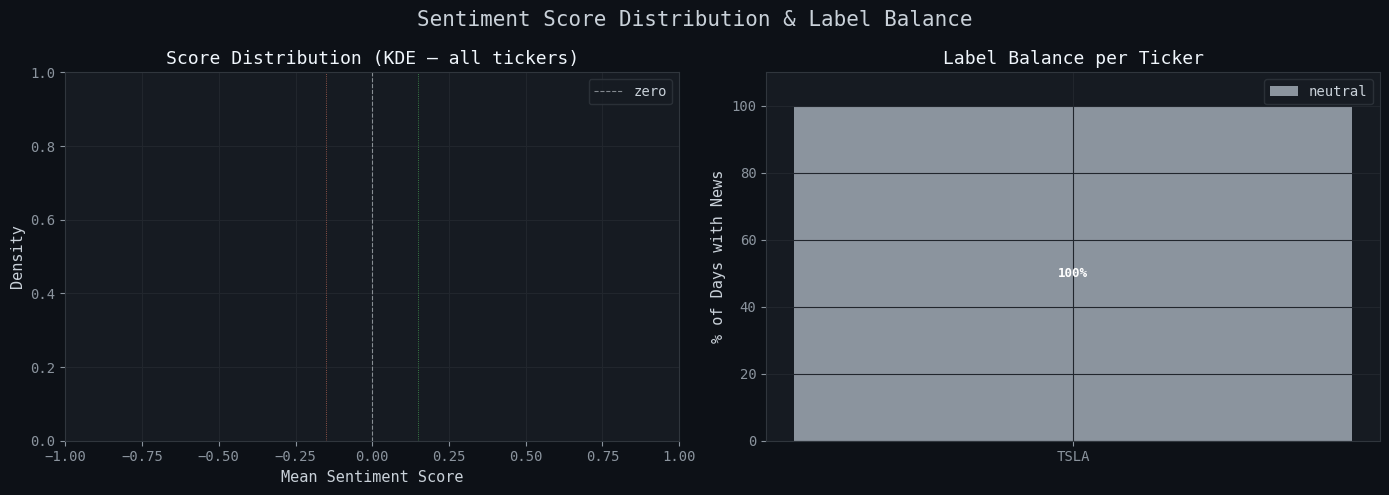

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Sentiment Score Distribution & Label Balance', fontsize=15)

ax = axes[0]
if 'mean_score' in df.columns:
    sc = df[df['mean_score'].notna() & (df['article_count'] > 0)]
    x_grid = np.linspace(-1, 1, 300)
    for ticker, g in sc.groupby('ticker'):
        vals = g['mean_score'].dropna().values
        if len(vals) < 3:
            continue
        kde = stats.gaussian_kde(vals, bw_method=0.3)
        ax.plot(x_grid, kde(x_grid), label=ticker, color=tc(ticker), linewidth=2)
        ax.fill_between(x_grid, kde(x_grid), alpha=0.08, color=tc(ticker))
    ax.axvline(0,     color='#f0f6fc', lw=0.8, ls='--', alpha=0.5, label='zero')
    ax.axvline( 0.15, color='#56d364', lw=0.6, ls=':',  alpha=0.7)
    ax.axvline(-0.15, color='#f78166', lw=0.6, ls=':',  alpha=0.7)
    ax.set_title('Score Distribution (KDE — all tickers)')
    ax.set_xlabel('Mean Sentiment Score')
    ax.set_ylabel('Density')
    ax.set_xlim(-1, 1)
    ax.legend()

ax2 = axes[1]
if 'dominant_label' in df.columns:
    lc = df[df['article_count'] > 0].groupby(['ticker','dominant_label']).size().unstack(fill_value=0)
    lp = lc.div(lc.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(lp))
    for label in ['bearish','neutral','bullish']:
        if label not in lp.columns: continue
        vals = lp[label].values
        ax2.bar(lp.index, vals, bottom=bottom, color=SENTIMENT_COLORS[label], label=label, width=0.5)
        for i,(v,b) in enumerate(zip(vals,bottom)):
            if v > 5:
                ax2.text(i, b+v/2, f'{v:.0f}%', ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')
        bottom += vals
ax2.set_title('Label Balance per Ticker')
ax2.set_ylabel('% of Days with News')
ax2.set_ylim(0, 110)
ax2.legend()
plt.tight_layout()
plt.show()


## 4 · News Coverage 
> ⚠ Coverage <40% = sparse signal — handle zero-news days explicitly in feature engineering.


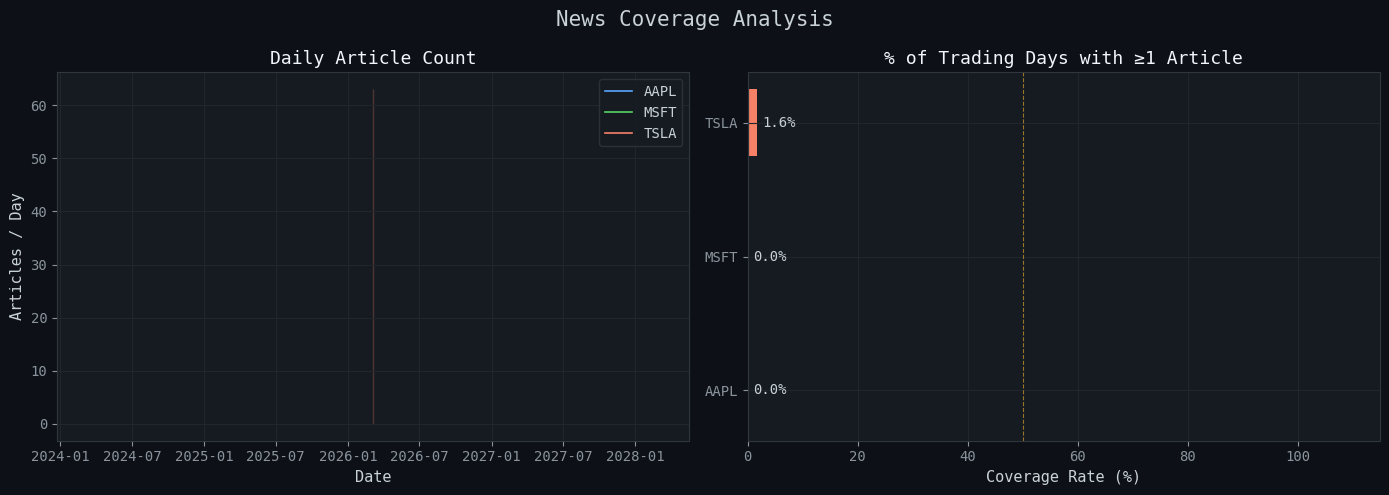

In [8]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('News Coverage Analysis', fontsize=15)

ax = axes[0]
for ticker, g in df.groupby('ticker'):
    g2 = g.set_index('date').sort_index()
    ax.fill_between(g2.index,g2['article_count'],alpha=0.25,color=tc(ticker))
    ax.plot(g2.index,g2['article_count'],color=tc(ticker),lw=1.2,label=ticker)
ax.set_title('Daily Article Count'); ax.set_xlabel('Date')
ax.set_ylabel('Articles / Day'); ax.legend()

ax2 = axes[1]
cov = df.groupby('ticker').apply(lambda g:(g['article_count']>0).mean()*100).reset_index(name='pct')
bars = ax2.barh(cov['ticker'],cov['pct'],color=[tc(t) for t in cov['ticker']],height=0.5)
for bar,val in zip(bars,cov['pct']):
    ax2.text(val+1,bar.get_y()+bar.get_height()/2,f'{val:.1f}%',va='center',fontsize=10)
ax2.axvline(50,color='#f0b429',lw=0.8,ls='--',alpha=0.6)
ax2.set_title('% of Trading Days with ≥1 Article'); ax2.set_xlabel('Coverage Rate (%)')
ax2.set_xlim(0,115)
plt.tight_layout(); plt.show()


## 5 · Sentiment → Next-Day Return (Q3)
> **Core question.** `r > 0, p < 0.05 ` = statistically significant.


In [ ]:
if 'mean_score' not in df.columns:
    print('Run Module 2 first.')
else:
    d2 = df.copy().sort_values(['ticker','date'])
    d2['next_ret'] = d2.groupby('ticker')['daily_return'].shift(-1)

    # ── guard: check we have scored rows before plotting ──────────────
    sc = d2[
        d2['mean_score'].notna() &
        d2['next_ret'].notna() &
        (d2['article_count'] > 0)
    ]
    if sc.empty:
        print('No scored rows with next-day return found.')
        print(f'  mean_score non-null : {d2["mean_score"].notna().sum()}')
        print(f'  next_ret non-null   : {d2["next_ret"].notna().sum()}')
        print(f'  article_count > 0   : {(d2["article_count"] > 0).sum()}')
        
    else:
        tickers = sc['ticker'].unique()
        ncols = max(1, len(tickers))  # never 0
        fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5), sharey=True)
        if ncols == 1: axes = [axes]
        fig.suptitle('Sentiment Score vs. Next-Day Return', fontsize=15)

        for ax, ticker in zip(axes, tickers):
            g = sc[sc['ticker'] == ticker]
            x, y = g['mean_score'].values, g['next_ret'].values * 100
            ax.scatter(x, y, alpha=0.45, s=22, color=tc(ticker), edgecolors='none')
            if len(x) > 5:
                slope, intercept, r, p, _ = stats.linregress(x, y)
                xl = np.linspace(x.min(), x.max(), 100)
                ax.plot(xl, slope*xl + intercept, color='#f0f6fc', lw=1.5, ls='--')
                sig = '✓' if p < 0.05 else '✗'
                ax.text(0.05, 0.93, f'r={r:.3f}  p={p:.3f} {sig}',
                        transform=ax.transAxes, fontsize=9, color='#f0f6fc',
                        bbox=dict(facecolor='#21262d', alpha=0.8, pad=3))
            ax.axhline(0, color='#8b949e', lw=0.6)
            ax.axvline(0, color='#8b949e', lw=0.6)
            ax.set_title(ticker, color=tc(ticker))
            ax.set_xlabel('Sentiment Score')
        axes[0].set_ylabel('Next-Day Return (%)')
        plt.tight_layout()
        plt.show()


No scored rows with next-day return found.
  mean_score non-null : 183
  next_ret non-null   : 180
  article_count > 0   : 1

→ Run Module 2 (sentiment pipeline) to populate mean_score.


## 6 · Sentiment + Price Over Time (Q4)
> Sentiment bars coloured green/red/grey. Leading spikes = predictive. Lagging = reactive.


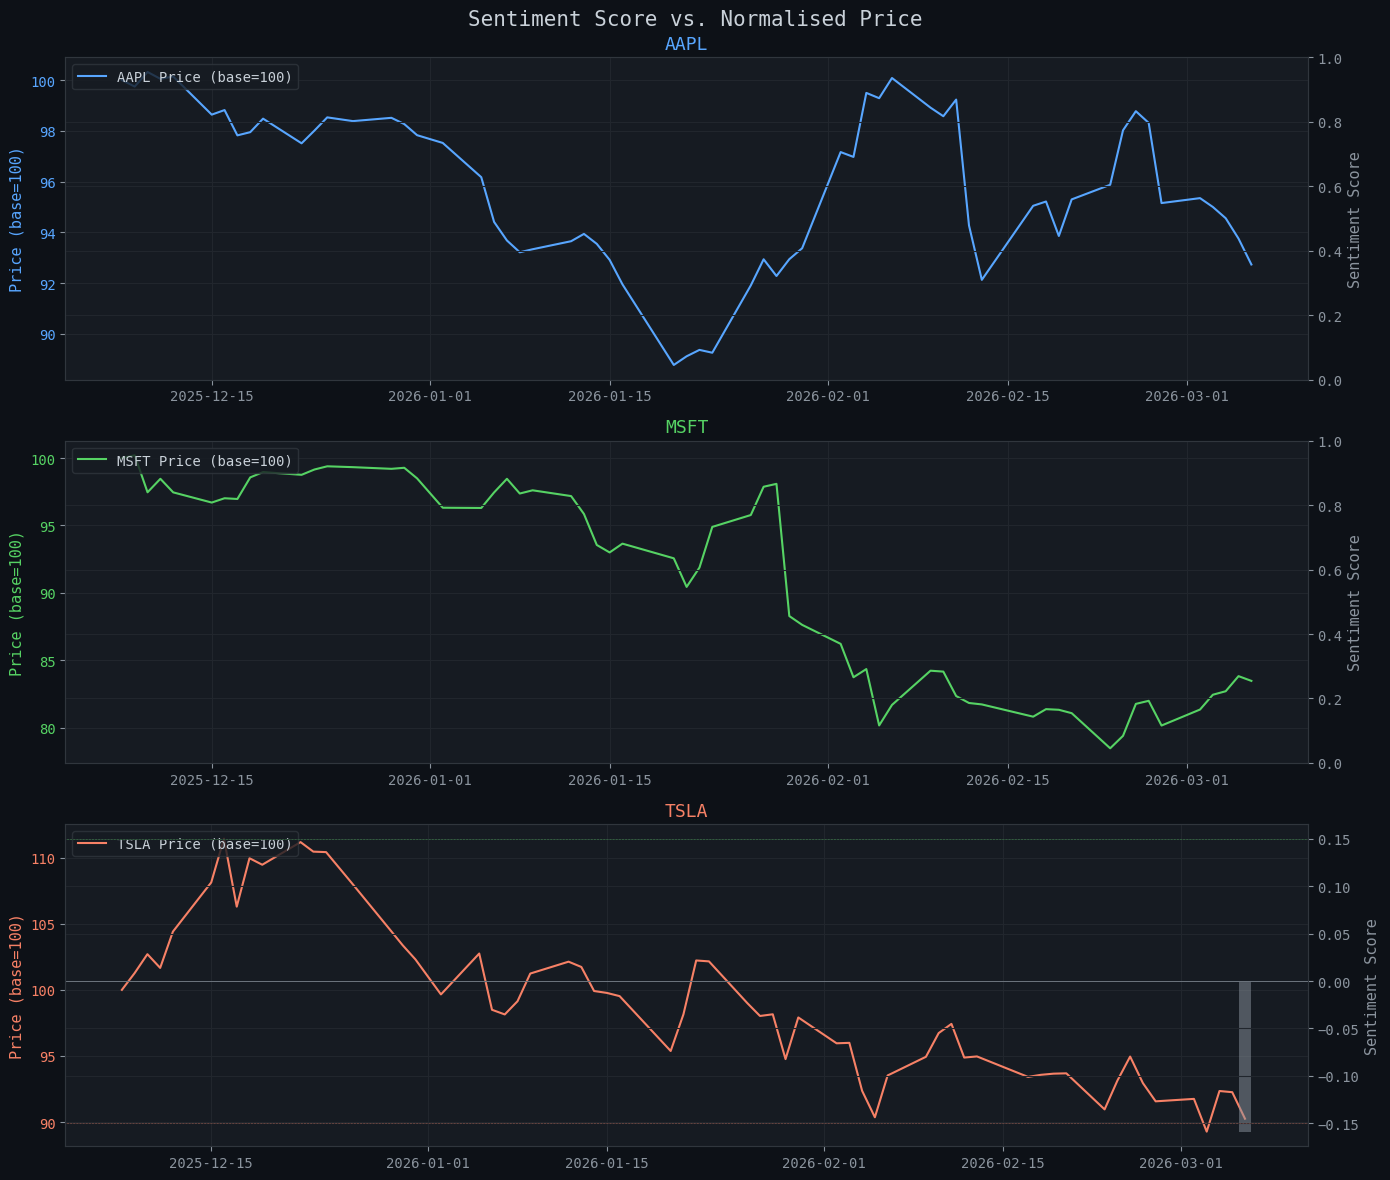

In [11]:
if 'mean_score' not in df.columns:
    print('Run Module 2 first.')
else:
    tickers = df['ticker'].unique()
    fig,axes = plt.subplots(len(tickers),1,figsize=(14,4*len(tickers)))
    if len(tickers)==1: axes=[axes]
    fig.suptitle('Sentiment Score vs. Normalised Price', fontsize=15)
    for ax,ticker in zip(axes,tickers):
        g = df[df['ticker']==ticker].set_index('date').sort_index()
        c = tc(ticker)
        norm = g['close']/g['close'].iloc[0]*100
        ax.plot(norm.index,norm.values,color=c,lw=1.5,label=f'{ticker} Price (base=100)')
        ax.set_ylabel('Price (base=100)',color=c); ax.tick_params(axis='y',labelcolor=c)
        ax2 = ax.twinx(); ax2.set_facecolor('#161b22')
        sd = g[g['mean_score'].notna()&(g['article_count']>0)]
        if len(sd)>0:
            bcols = [SENTIMENT_COLORS.get(str(l),'#8b949e') for l in sd.get('dominant_label',['neutral']*len(sd))]
            ax2.bar(sd.index,sd['mean_score'],color=bcols,alpha=0.5,width=1)
            ax2.axhline(0,color='#8b949e',lw=0.5)
            ax2.axhline( 0.15,color='#56d364',lw=0.4,ls=':')
            ax2.axhline(-0.15,color='#f78166',lw=0.4,ls=':')
        ax2.set_ylabel('Sentiment Score',color='#8b949e')
        ax2.tick_params(axis='y',labelcolor='#8b949e')
        ax.set_title(ticker,color=c); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()


## 7 · Lag Correlation Analysis (Q5)
> The bar with highest `|r|` tells you which lag to prioritise in Module 3.  `* p<0.05  ** p<0.01`


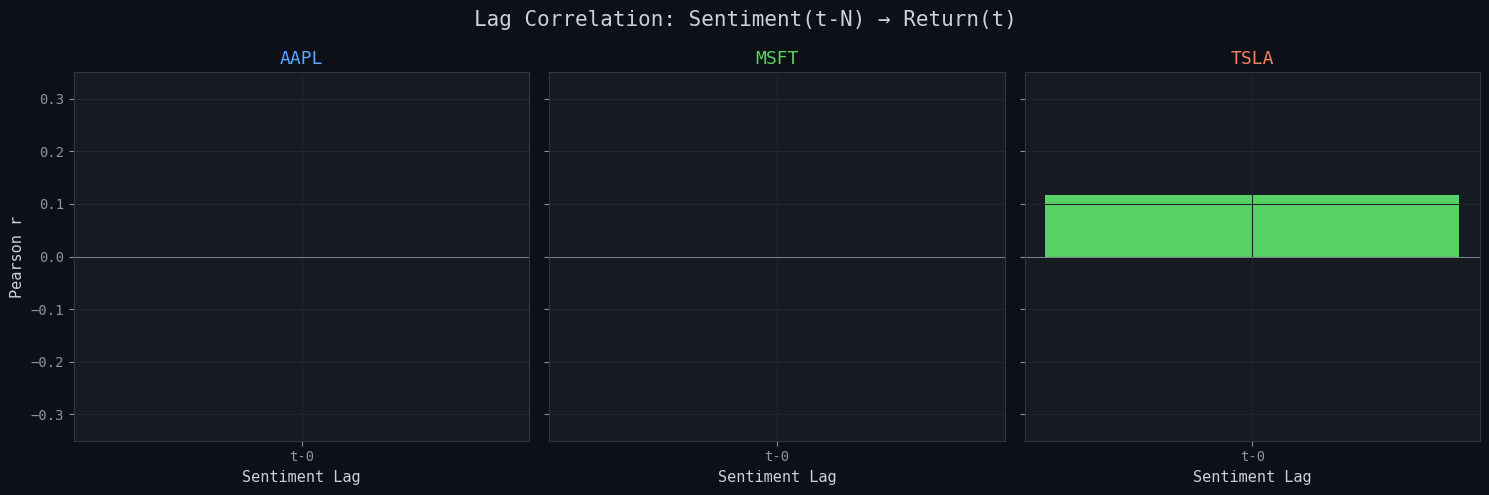

In [12]:
if 'mean_score' not in df.columns:
    print('Run Module 2 first.')
else:
    lags = list(range(0,6))
    tickers = df['ticker'].unique()
    ncols = max(1, len(tickers))
    fig,axes = plt.subplots(1,ncols,figsize=(5*ncols,5),sharey=True)
    if ncols==1: axes=[axes]
    fig.suptitle('Lag Correlation: Sentiment(t-N) → Return(t)', fontsize=15)
    for ax,ticker in zip(axes,tickers):
        g = df[df['ticker']==ticker].sort_values('date').copy()
        g = g[g['mean_score'].notna()]
        rs,ps = [],[]
        for lag in lags:
            g[f'sl{lag}'] = g['mean_score'].shift(lag)
            pair = g[['daily_return',f'sl{lag}']].dropna()
            if len(pair)>10:
                r,p = stats.pearsonr(pair[f'sl{lag}'],pair['daily_return'])
            else: r,p = 0.0,1.0
            rs.append(r); ps.append(p)
        colors = ['#56d364' if r>=0 else '#f78166' for r in rs]
        bars = ax.bar([f't-{l}' for l in lags],rs,color=colors,width=0.6)
        for bar,r,p in zip(bars,rs,ps):
            mark = '**' if p<0.01 else ('*' if p<0.05 else '')
            if mark:
                ax.text(bar.get_x()+bar.get_width()/2,r+(0.003 if r>=0 else -0.008),
                        mark,ha='center',fontsize=12,color=tc(ticker))
        ax.axhline(0,color='#8b949e',lw=0.6)
        ax.set_title(ticker,color=tc(ticker)); ax.set_xlabel('Sentiment Lag'); ax.set_ylim(-0.35,0.35)
    axes[0].set_ylabel('Pearson r')
    plt.tight_layout(); plt.show()


## 8 · Cross-Ticker Statistics Heatmap (Q6)
> Green = relatively high, Red = relatively low. Compare return on bullish vs bearish days.


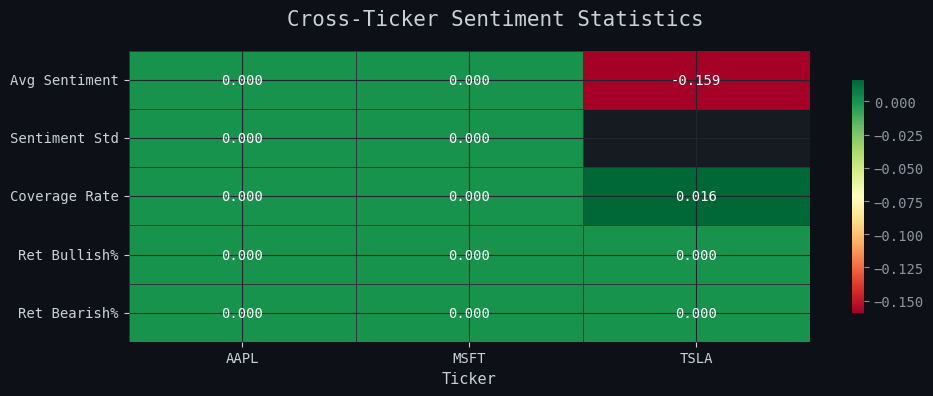

In [13]:
if 'mean_score' not in df.columns:
    print('Run Module 2 first.')
else:
    rows=[]
    for ticker,g in df.groupby('ticker'):
        sc = g[g['mean_score'].notna()&(g['article_count']>0)]
        gs = g.sort_values('date').copy(); gs['nr']=gs['daily_return'].shift(-1)
        br = gs[gs.get('dominant_label','')=='bullish']['nr'].mean() if 'dominant_label' in gs.columns else None
        er = gs[gs.get('dominant_label','')=='bearish']['nr'].mean() if 'dominant_label' in gs.columns else None
        rows.append({
            'Ticker':ticker,'Avg Sentiment':round(sc['mean_score'].mean(),3) if len(sc)>0 else 0,
            'Sentiment Std':round(sc['mean_score'].std(),3) if len(sc)>0 else 0,
            'Coverage Rate':round((g['article_count']>0).mean(),3),
            'Ret Bullish%':round(br*100,3) if br and pd.notna(br) else 0,
            'Ret Bearish%':round(er*100,3) if er and pd.notna(er) else 0,
        })
    sdf = pd.DataFrame(rows).set_index('Ticker')
    fig,ax = plt.subplots(figsize=(10,4))
    fig.suptitle('Cross-Ticker Sentiment Statistics', fontsize=15)
    sns.heatmap(sdf.T,annot=True,fmt='.3f',cmap='RdYlGn',ax=ax,
                linewidths=0.5,linecolor='#30363d',cbar_kws={'shrink':0.8})
    ax.tick_params(axis='x',colors='#c9d1d9'); ax.tick_params(axis='y',colors='#c9d1d9')
    plt.tight_layout(); plt.show()


## 9 · Sentiment Momentum Distribution (Q7)
> High skew = directional drift. Fat tails = frequent sharp reversals — useful as a feature.


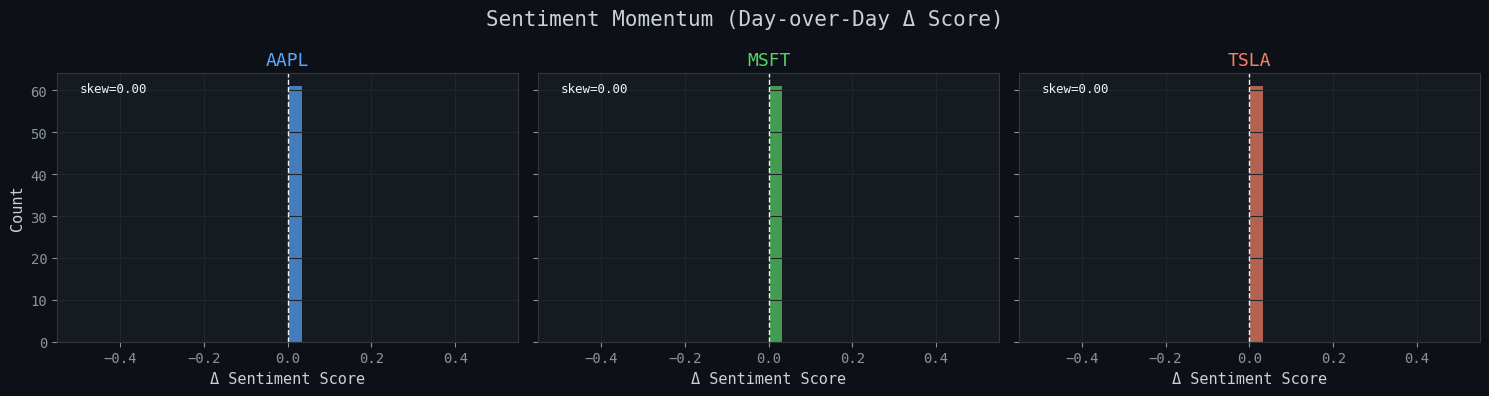

In [14]:
if 'sentiment_momentum' not in df.columns or df['sentiment_momentum'].isna().all():
    print('sentiment_momentum filled by Module 2 aggregator.')
else:
    mom = df[df['sentiment_momentum'].notna()]
    tickers = mom['ticker'].unique()
    fig,axes = plt.subplots(1,len(tickers),figsize=(5*len(tickers),4),sharey=True)
    if len(tickers)==1: axes=[axes]
    fig.suptitle('Sentiment Momentum (Day-over-Day Δ Score)', fontsize=15)
    for ax,ticker in zip(axes,tickers):
        g = mom[mom['ticker']==ticker]
        ax.hist(g['sentiment_momentum'],bins=30,color=tc(ticker),alpha=0.7,edgecolor='none')
        ax.axvline(0,color='#f0f6fc',lw=1,ls='--')
        ax.text(0.05,0.93,f'skew={g["sentiment_momentum"].skew():.2f}',
                transform=ax.transAxes,fontsize=9,color='#f0f6fc')
        ax.set_title(ticker,color=tc(ticker)); ax.set_xlabel('Δ Sentiment Score')
    axes[0].set_ylabel('Count')
    plt.tight_layout(); plt.show()


## 10 · Outlier Days (Q8)
> ◆ Diamond = `|return|>2σ` OR `|score|>0.5`. Check these dates — earnings, macro shocks, or data errors.


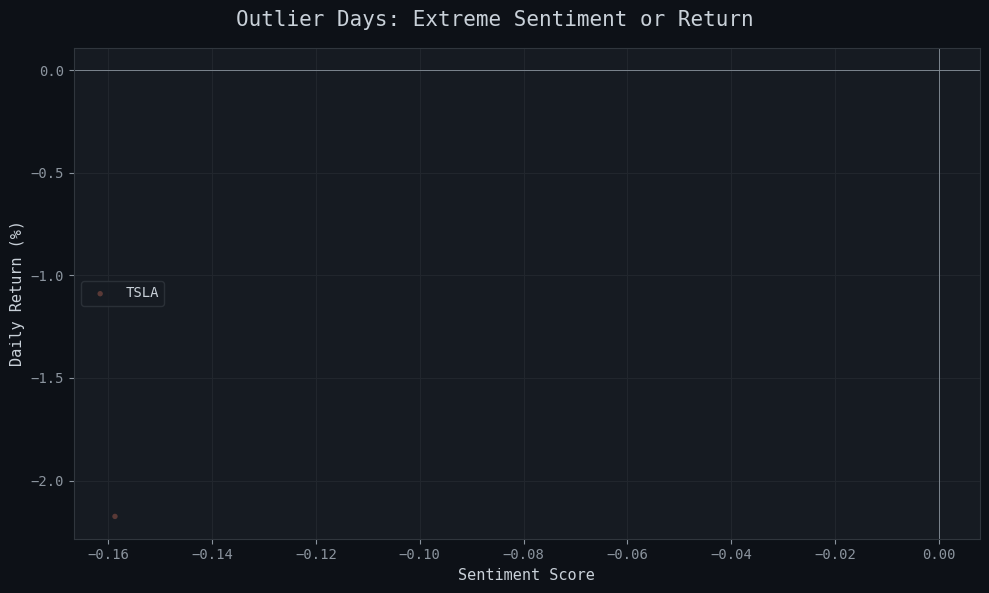


Top-10 Outlier Days:


,ticker,date,mean_score,daily_return,article_count


In [15]:
if 'mean_score' not in df.columns:
    print('Run Module 2 first.')
else:
    sc = df[df['mean_score'].notna()&df['daily_return'].notna()&(df['article_count']>0)].copy()
    if not sc.empty:
        ret_std = sc['daily_return'].std()
        sc['outlier'] = (sc['daily_return'].abs()>2*ret_std)|(sc['mean_score'].abs()>0.5)
        fig,ax = plt.subplots(figsize=(10,6))
        fig.suptitle('Outlier Days: Extreme Sentiment or Return', fontsize=15)
        for ticker,g in sc.groupby('ticker'):
            norm=g[~g['outlier']]; ext=g[g['outlier']]; c=tc(ticker)
            ax.scatter(norm['mean_score'],norm['daily_return']*100,alpha=0.3,s=15,color=c,edgecolors='none',label=ticker)
            ax.scatter(ext['mean_score'],ext['daily_return']*100,alpha=0.9,s=60,color=c,edgecolors='#f0f6fc',lw=0.8,marker='D')
        ax.axhline(0,color='#8b949e',lw=0.6); ax.axvline(0,color='#8b949e',lw=0.6)
        ax.set_xlabel('Sentiment Score'); ax.set_ylabel('Daily Return (%)'); ax.legend()
        plt.tight_layout(); plt.show()
        out = sc[sc['outlier']][['ticker','date','mean_score','daily_return','article_count']].copy()
        out['daily_return']=(out['daily_return']*100).round(2); out['mean_score']=out['mean_score'].round(3)
        out = out.sort_values('daily_return',key=abs,ascending=False).head(10)
        print('\nTop-10 Outlier Days:')
        display(out.reset_index(drop=True))


## 11 · Rolling 30-Day Correlation (Q10)
> Flat line = stable signal (good for modelling). Wild swings = regime-dependent — add regime features in Module 3.


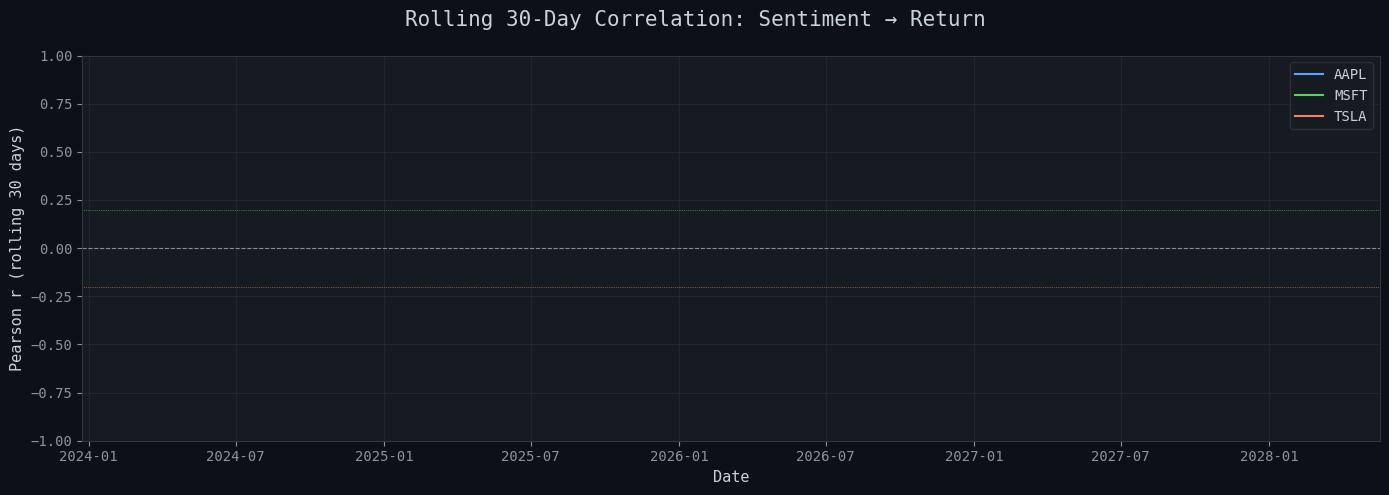

In [16]:
if 'mean_score' not in df.columns:
    print('Run Module 2 first.')
else:
    fig,ax = plt.subplots(figsize=(14,5))
    fig.suptitle('Rolling 30-Day Correlation: Sentiment → Return', fontsize=15)
    for ticker,g in df.groupby('ticker'):
        g2 = g.sort_values('date').set_index('date')
        g2 = g2[g2['mean_score'].notna()&g2['daily_return'].notna()]
        if len(g2)<35: continue
        rc = g2['mean_score'].rolling(30).corr(g2['daily_return'])
        ax.plot(rc.index,rc.values,color=tc(ticker),lw=1.5,label=ticker)
    ax.axhline(0,color='#f0f6fc',lw=0.8,ls='--',alpha=0.5)
    ax.axhline( 0.2,color='#56d364',lw=0.5,ls=':')
    ax.axhline(-0.2,color='#f78166',lw=0.5,ls=':')
    ax.set_ylabel('Pearson r (rolling 30 days)'); ax.set_xlabel('Date')
    ax.set_ylim(-1,1); ax.legend()
    plt.tight_layout(); plt.show()
